---
title: "Volatility Forecasts (Part 6: Channel-Allocated XGBPGARCH)"
date: 2026-03-22
description: "Part 6 introduces hard channel-specific feature allocation and per-channel screening, fitting PGARCH-L and full XGBPGARCH to an expanded feature set."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 6
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Introduction

[Part 5](../volatility-forecasts-5/) established the PGARCH reparametrization of the GARCH(1,1) recursion into three interpretable channels: a long-run variance level $\mu$, a persistence weight $\phi$, and a shock-loading share $g$. A central finding was that fast return features cannot cleanly identify a time-varying $\mu$: the constant-$\mu$ variants provided the cleanest structural interpretation. Part 5 also introduced the XGB-g-PGARCH, a hybrid in which a `gblinear` booster refines the $g$ channel on top of a linear PGARCH-L initialiser. With only three return features and a linear booster, the XGB layer added no signal beyond the initialiser — a mathematical consequence of applying a linear correction to an already-optimal linear model.

This post extends the analysis in three directions. First, we expand the feature set from three return features to a richer pool of approximately fifty predictors, spanning trailing realised volatility at multiple horizons, intraday return decompositions, cross-asset indicators, macro conditions, financial stress measures, and calendar effects. Second, we introduce per-channel feature screening: rather than feeding all features to all channels, the $\phi$ and $g$ channels each select their own top-$K$ features ranked by coefficient magnitude, while $\mu$ remains constant. Third, we move from the single-channel `gblinear` booster of Part 5 to the full XGBPGARCH, in which independent boosters update both $\phi$ and $g$ simultaneously, and we compare `gblinear` against `gbtree` to assess whether nonlinear feature interactions add value beyond the screened linear specification.



In [1]:
#| echo: false
#| output: false

import sys
import os
import logging
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler

# --- PATH SETUP ---
WORKSPACE_CANDIDATES = [
    Path("/Users/steveyang/Projects/steveya"),
    Path("/Users/steveyang/Projects/Github"),
    Path.cwd(),
]
WORKSPACE_ROOT = next(
    (
        p for p in WORKSPACE_CANDIDATES
        if (p / "steveya.github.io").exists()
        and (p / "volatility-forecast").exists()
        and (p / "alphaforge").exists()
    ),
    None,
)
if WORKSPACE_ROOT is None:
    raise RuntimeError(
        "Could not locate a workspace root containing steveya.github.io, volatility-forecast, and alphaforge."
    )

BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
load_dotenv(BLOG_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx, build_vol_dataset, VolDatasetSpec
from volatility_forecast.sources import TiingoEODSource
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano
from volatility_forecast.evaluation.mz import mincer_zarnowitz

from volatility_forecast.model.pgarch_linear_model import PGARCHLinearModel
from volatility_forecast.model.xgb_pgarch_full_model import XGBPGARCHModel

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# --- CACHE ---
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/steveya/volatility-forecast/.af_cache
Tiingo cache mode: use


In [2]:
#| echo: false
#| output: false

from arch import arch_model
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget

# --- SAMPLE PARAMETERS (identical to Part 5) ---
SAMPLE_TICKER = "SPY"
SAMPLE_START = pd.Timestamp("2000-01-01", tz="UTC")
SAMPLE_END = pd.Timestamp("2023-12-31", tz="UTC")
SAMPLE_TRAIN_START = 200
SAMPLE_SPLIT_INDEX = 4000
SCALE_FACTOR = 100.0

# --- CACHE PREFLIGHT ---
sample_cache_key = f"{SAMPLE_TICKER}|adj=True"
sample_cached = cache.get(sample_cache_key)
if sample_cached is None or sample_cached.empty:
    raise RuntimeError(f"Cache-only mode: no cached data for key={sample_cache_key}.")

sample_cached = sample_cached.copy()
sample_cached["date"] = pd.to_datetime(sample_cached["date"], utc=True).dt.normalize()

# --- BUILD DATASET (same spec as Part 5) ---
def _build_spec(source, ticker, start, end, lags=0):
    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=(
            FeatureRequest(
                template=LagLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagAbsLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagSquaredLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
        ),
        target=TargetRequest(
            template=NextDaySquaredReturnTarget(),
            params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
            horizon=1,
            name="y",
        ),
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )

ctx_sample = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)
X_raw, y_raw, r_raw, _ = build_vol_dataset(
    ctx_sample,
    _build_spec("tiingo", SAMPLE_TICKER, SAMPLE_START, SAMPLE_END),
    persist=False,
)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par, y_par, r_par = X_par.loc[common_idx], y_par.loc[common_idx], r_par.loc[common_idx]

# --- FIXED SPLIT ---
X_tr = X_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_te = X_par.iloc[SAMPLE_SPLIT_INDEX:]
y_tr = y_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
y_te = y_par.iloc[SAMPLE_SPLIT_INDEX:]
r_tr = r_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
r_te = r_par.iloc[SAMPLE_SPLIT_INDEX:]
y_all = pd.concat([y_tr, y_te])
r_all = pd.concat([r_tr, r_te])
target_idx = y_par.index

# PGARCH feature columns (no const — model adds its own intercept)
base_feat_cols = [c for c in X_par.columns if c != "const"]

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} -> {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} -> {X_te.index.max().date()})")
print(f"Baseline features: {base_feat_cols}")

Train rows: 3800 (2000-10-18 -> 2015-11-25)
Test rows:  2035 (2015-11-27 -> 2023-12-28)
Baseline features: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10']


In [3]:
#| code-fold: true
#| code-summary: "Build expanded feature set"

# ── Shared OHLCV data ──────────────────────────────────────────────────────────────────────
ohlcv = sample_cached.set_index("date")[["open", "close", "volume"]].copy()
ohlcv.index = pd.DatetimeIndex(ohlcv.index)
ohlcv = ohlcv.sort_index()
ohlcv_aligned = ohlcv.reindex(target_idx, method="ffill")

# ── 1. Intraday return decomposition ─────────────────────────────────────────────
intra_df = pd.DataFrame(index=target_idx)
prev_close = ohlcv_aligned["close"].shift(1)
intra_df["overnight_return"] = np.log(ohlcv_aligned["open"] / prev_close)
intra_df["intraday_return"] = np.log(ohlcv_aligned["close"] / ohlcv_aligned["open"])
intra_df["overnight_sq"] = intra_df["overnight_return"] ** 2
intra_df["intraday_sq"] = intra_df["intraday_return"] ** 2
intra_df = intra_df.fillna(0.0)
intraday_cols = list(intra_df.columns)

# ── 2. HAR multi-horizon realised volatility ─────────────────────────────────────
rv_daily = r_par ** 2
har_df = pd.DataFrame(index=target_idx)
har_df["rv_1"] = rv_daily.shift(1)
har_df["rv_5"] = rv_daily.rolling(5, min_periods=1).mean().shift(1)
har_df["rv_22"] = rv_daily.rolling(22, min_periods=1).mean().shift(1)
har_df["rv_60"] = rv_daily.rolling(60, min_periods=1).mean().shift(1)
har_df["rv_ratio_5_22"] = har_df["rv_5"] / har_df["rv_22"].clip(lower=1e-12)
har_df = har_df.fillna(0.0)
har_rv_cols = list(har_df.columns)

# ── 3. Downside asymmetry and leverage effect ────────────────────────────────────
neg_mask = (r_par < 0).astype(float)
pos_mask = (r_par >= 0).astype(float)
rv_daily_asym = r_par ** 2

asym_df = pd.DataFrame(index=target_idx)
neg_rv = (rv_daily_asym * neg_mask).rolling(22, min_periods=1).sum().shift(1)
pos_rv = (rv_daily_asym * pos_mask).rolling(22, min_periods=1).sum().shift(1)
asym_df["neg_semi_rv_22"] = neg_rv
asym_df["pos_neg_rv_ratio"] = pos_rv / neg_rv.clip(lower=1e-12)
asym_df["signed_rv_interaction"] = (r_par * rv_daily_asym).shift(1)
asym_df["downside_freq_22"] = neg_mask.rolling(22, min_periods=1).mean().shift(1)
asym_df = asym_df.fillna(0.0)
asym_cols = list(asym_df.columns)

# ── 4. Volatility-of-volatility and regime dispersion ────────────────────────────
rv_daily_vov = r_par ** 2
vov_df = pd.DataFrame(index=target_idx)
vov_df["vov_22"] = rv_daily_vov.rolling(22, min_periods=5).std().shift(1)
rv_max_22 = rv_daily_vov.rolling(22, min_periods=5).max().shift(1)
rv_min_22 = rv_daily_vov.rolling(22, min_periods=5).min().shift(1)
vov_df["rv_range_22"] = rv_max_22 - rv_min_22
rv_lag1 = rv_daily_vov.shift(1)
vov_df["rv_autocorr_5"] = rv_daily_vov.rolling(5, min_periods=3).corr(rv_lag1).shift(1)
vov_df = vov_df.fillna(0.0)
vov_cols = list(vov_df.columns)

# ── 5. Volume and liquidity ──────────────────────────────────────────────────────
vol_df = pd.DataFrame(index=target_idx)
spy_vol_aligned = ohlcv_aligned["volume"]
spy_close_aligned = ohlcv_aligned["close"]
vol_df["volume_ratio"] = spy_vol_aligned / spy_vol_aligned.rolling(20, min_periods=1).mean()
dollar_volume = spy_close_aligned * spy_vol_aligned
vol_df["amihud_illiq"] = (r_par.abs() / dollar_volume) * 1e6
vol_df = vol_df.fillna(0.0)
volume_cols = list(vol_df.columns)

# ── 6. Calendar and event features ───────────────────────────────────────────────
try:
    from alphaforge.features import CalendarFlagsTemplate, EventDateTemplate
    from alphaforge.features.template import SliceSpec as AFSliceSpec

    cal_tmpl = CalendarFlagsTemplate()
    cal_slice = AFSliceSpec(start=SAMPLE_START, end=SAMPLE_END, entities=[SAMPLE_TICKER])
    cal_ff = cal_tmpl.transform(
        ctx_sample,
        params={
            "calendar": "XNYS",
            "flags": ("dow", "is_month_end", "is_quarter_end", "is_year_end"),
            "one_hot_dow": True,
        },
        slice=cal_slice,
        state=None,
    )
    if isinstance(cal_ff.index, pd.MultiIndex):
        cal_ff = cal_ff.xs(SAMPLE_TICKER, level="entity_id")
    cal_ff = cal_ff.reindex(target_idx).fillna(0.0)

    evt_tmpl = EventDateTemplate()
    evt_ff = evt_tmpl.transform(
        ctx_sample,
        params={
            "calendar": "XNYS",
            "events": ("fomc", "opex", "imm"),
            "near_window": 3,
        },
        slice=cal_slice,
        state=None,
    )
    if isinstance(evt_ff.index, pd.MultiIndex):
        evt_ff = evt_ff.xs(SAMPLE_TICKER, level="entity_id")
    evt_ff = evt_ff.reindex(target_idx).fillna(0.0)

    seasonal_df = pd.concat([cal_ff, evt_ff], axis=1)
    for col_end in ["is_month_end", "is_quarter_end", "is_year_end"]:
        if col_end in seasonal_df.columns:
            lead_col = col_end.replace("is_", "pre_") + "_3d"
            end_positions = seasonal_df[col_end] == 1
            lead_series = pd.Series(0.0, index=target_idx)
            for idx_pos in end_positions[end_positions].index:
                loc = target_idx.get_loc(idx_pos)
                for lag in range(1, 4):
                    if loc - lag >= 0:
                        lead_series.iloc[loc - lag] = 1.0
            seasonal_df[lead_col] = lead_series
    seasonal_cols = list(seasonal_df.columns)
    _cal_ok = True
    print(f"Calendar/event features: {len(seasonal_cols)} columns")
except Exception as e:
    print(f"Calendar features unavailable ({e}); building minimal DOW flags")
    seasonal_df = pd.DataFrame(index=target_idx)
    dow = target_idx.dayofweek
    for d in range(5):
        seasonal_df[f"dow_{d}"] = (dow == d).astype(float)
    seasonal_cols = list(seasonal_df.columns)
    _cal_ok = False

# ── 7. FRED-based features ───────────────────────────────────────────────────────
_fred_ok = False
fred_feature_dfs = []
fred_feature_cols = []
try:
    from fredapi import Fred
    fred = Fred(api_key=os.environ["FRED_API_KEY"])
    _start = SAMPLE_START.strftime("%Y-%m-%d")
    _end = SAMPLE_END.strftime("%Y-%m-%d")

    def _fred_to_daily(s, col_name, tidx):
        s = s.rename(col_name)
        s.index = pd.DatetimeIndex(s.index)
        if tidx.tz is not None:
            s.index = s.index.tz_localize("UTC") if s.index.tz is None else s.index.tz_convert("UTC")
        else:
            s.index = s.index.tz_localize(None) if s.index.tz is not None else s.index
        return s.reindex(tidx, method="ffill")

    vix_df = pd.DataFrame(index=target_idx)
    vix_series = fred.get_series("VIXCLS", observation_start=_start, observation_end=_end).dropna()
    vix_df["vix_level"] = _fred_to_daily(vix_series, "vix_level", target_idx)
    vix_df["vix_change"] = vix_df["vix_level"].diff().fillna(0.0)
    vix_df["vix_level"] = vix_df["vix_level"].ffill().bfill()
    try:
        vix3m = fred.get_series("VXVCLS", observation_start=_start, observation_end=_end).dropna()
        vix_df["vix_term_slope"] = _fred_to_daily(vix_series, "v1", target_idx) - _fred_to_daily(vix3m, "v2", target_idx)
        vix_df["vix3m_available"] = _fred_to_daily(vix3m, "v3", target_idx).notna().astype(float)
    except Exception:
        vix_df["vix_term_slope"] = 0.0
        vix_df["vix3m_available"] = 0.0
    rv_20_annualised = np.sqrt(rv_daily.rolling(20, min_periods=5).mean().shift(1) * 252) * 100
    vix_df["iv_rv_spread"] = vix_df["vix_level"] - rv_20_annualised
    vix_df = vix_df.fillna(0.0)
    vix_cols = list(vix_df.columns)
    fred_feature_dfs.append(vix_df[vix_cols])

    cross_df = pd.DataFrame(index=target_idx)
    fred_cross = {
        "BAMLH0A0HYM2": "credit_spread",
        "T10Y2Y": "curve_slope",
        "DCOILWTICO": "oil_price",
        "DGS2": "short_rate_level",
        "DGS10": "long_rate_level",
        "DTWEXBGS": "usd_level",
    }
    for fred_id, col_name in fred_cross.items():
        try:
            s = fred.get_series(fred_id, observation_start=_start, observation_end=_end).dropna()
            cross_df[col_name] = _fred_to_daily(s, col_name, target_idx)
        except Exception:
            cross_df[col_name] = np.nan

    try:
        copper_monthly = fred.get_series("PCOPPUSDM", observation_start=_start, observation_end=_end).dropna()
        cross_df["copper_level"] = _fred_to_daily(copper_monthly, "copper_level", target_idx)
    except Exception:
        cross_df["copper_level"] = np.nan

    try:
        gld_src = TiingoEODSource(api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"))
        gld_raw = gld_src.fetch(Query(
            table="market.ohlcv", columns=["close"],
            start=SAMPLE_START, end=SAMPLE_END, entities=["GLD"],
        ))
        gld_close = gld_raw.set_index("date")["close"].rename("gold_price")
        if target_idx.tz is None:
            gld_close.index = pd.DatetimeIndex(gld_close.index).tz_localize(None)
        else:
            gld_close.index = pd.DatetimeIndex(gld_close.index).tz_convert(target_idx.tz)
        cross_df["gold_price"] = gld_close.reindex(target_idx, method="ffill")
    except Exception:
        cross_df["gold_price"] = np.nan

    cross_df["gold_return"] = np.log(cross_df["gold_price"] / cross_df["gold_price"].shift(1))
    cross_df["oil_return"] = np.log(cross_df["oil_price"] / cross_df["oil_price"].shift(1))
    cross_df["copper_change"] = cross_df["copper_level"].pct_change()
    cross_df["short_rate_change"] = cross_df["short_rate_level"].diff()
    cross_df["long_rate_change"] = cross_df["long_rate_level"].diff()
    cross_df["usd_change"] = cross_df["usd_level"].pct_change()
    cross_df["usd_available"] = cross_df["usd_level"].notna().astype(float)

    for col in ["credit_spread", "curve_slope", "short_rate_level", "long_rate_level",
                 "usd_level", "copper_level"]:
        cross_df[col] = cross_df[col].ffill().bfill()
    for col in ["gold_return", "oil_return", "copper_change",
                 "short_rate_change", "long_rate_change", "usd_change"]:
        cross_df[col] = cross_df[col].fillna(0.0)
    cross_df["usd_level"] = cross_df["usd_level"].ffill().bfill()
    cross_df = cross_df.drop(columns=["oil_price", "gold_price"], errors="ignore")
    cross_asset_cols = [c for c in cross_df.columns if c not in ("oil_price", "gold_price")]
    cross_df = cross_df[cross_asset_cols].fillna(0.0)
    fred_feature_dfs.append(cross_df)

    stress_df = pd.DataFrame(index=target_idx)
    stress_series = {
        "VVIXCLS": "vvix_level",
        "NFCI": "nfci_level",
        "STLFSI4": "stlfsi_level",
        "TEDRATE": "ted_spread",
    }
    for fred_id, col_name in stress_series.items():
        try:
            s = fred.get_series(fred_id, observation_start=_start, observation_end=_end).dropna()
            stress_df[col_name] = _fred_to_daily(s, col_name, target_idx)
        except Exception:
            stress_df[col_name] = np.nan
    stress_df = stress_df.ffill().bfill().fillna(0.0)
    stress_cols = list(stress_df.columns)
    fred_feature_dfs.append(stress_df)

    macro_df = pd.DataFrame(0.0, index=target_idx, columns=[])
    trading_dates = target_idx
    macro_release_series = {"gdp": "GDP", "cpi": "CPIAUCSL", "nfp": "PAYEMS"}
    for label, fred_id in macro_release_series.items():
        try:
            vintages = fred.get_series_vintage_dates(fred_id)
            release_dates = pd.DatetimeIndex(vintages)
            if trading_dates.tz is not None:
                release_dates = release_dates.tz_localize("UTC") if release_dates.tz is None else release_dates.tz_convert("UTC")
            else:
                release_dates = release_dates.tz_localize(None) if release_dates.tz is not None else release_dates
            release_dates = release_dates.normalize()
            macro_df[f"is_{label}_release"] = trading_dates.isin(release_dates).astype(float)
            pre_col = f"pre_{label}_1d"
            shifted_releases = release_dates - pd.tseries.offsets.BDay(1)
            macro_df[pre_col] = trading_dates.isin(shifted_releases).astype(float)
        except Exception as e:
            print(f"  Macro release {label} unavailable: {e}")
            macro_df[f"is_{label}_release"] = 0.0
            macro_df[f"pre_{label}_1d"] = 0.0
    macro_cols = list(macro_df.columns)
    fred_feature_dfs.append(macro_df)

    _fred_ok = True
    for _df in fred_feature_dfs:
        fred_feature_cols.extend(list(_df.columns))
    print(f"FRED-based features: {len(fred_feature_cols)} columns")
except Exception as e:
    print(f"FRED features unavailable ({e}); proceeding without them")
    _fred_ok = False

# ── Assemble the expanded feature matrix ─────────────────────────────────────────
expanded_parts = [X_par[base_feat_cols]]
expanded_parts.extend([intra_df, har_df, asym_df, vov_df, vol_df])
expanded_parts.append(seasonal_df)
if _fred_ok:
    expanded_parts.extend(fred_feature_dfs)

X_expanded = pd.concat(expanded_parts, axis=1)
X_expanded = X_expanded.fillna(0.0)
X_expanded = X_expanded.loc[:, ~X_expanded.columns.duplicated()]

expanded_feat_cols = list(X_expanded.columns)

X_exp_tr = X_expanded.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_exp_te = X_expanded.iloc[SAMPLE_SPLIT_INDEX:]
X_exp_all = pd.concat([X_exp_tr, X_exp_te])

print(f"\nExpanded feature matrix: {X_expanded.shape[1]} columns")
print(f"  Train: {X_exp_tr.shape}, Test: {X_exp_te.shape}")

Calendar features unavailable ('FeatureFrame' object has no attribute 'index'); building minimal DOW flags


/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


FRED-based features: 28 columns

Expanded feature matrix: 54 columns
  Train: (3800, 54), Test: (2035, 54)


In [4]:
#| code-fold: true
#| code-summary: "Fit GARCH(1,1) baseline"

r_tr_pct = r_tr * SCALE_FACTOR
r_all_concat = pd.concat([r_tr, r_te])
r_all_pct = r_all_concat * SCALE_FACTOR

garch_spec = arch_model(r_tr_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit = garch_spec.fit(disp="off")
omega_g, alpha_g, beta_g = (
    garch_fit.params["omega"],
    garch_fit.params["alpha[1]"],
    garch_fit.params["beta[1]"],
)

cv_sq_is = garch_fit.conditional_volatility.values ** 2
r_sq_is = r_tr_pct.values ** 2
garch_pred_is = (omega_g + alpha_g * r_sq_is + beta_g * cv_sq_is) / (SCALE_FACTOR ** 2)

garch_spec_full = arch_model(r_all_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit_full = garch_spec_full.fit(disp="off", last_obs=len(r_tr))
garch_fcast = garch_fit_full.forecast(start=len(r_tr), reindex=False)
garch_pred_os = garch_fcast.variance.values.flatten() / (SCALE_FACTOR ** 2)

print(f"GARCH(1,1): omega={omega_g:.6f}, alpha={alpha_g:.4f}, beta={beta_g:.4f}")

GARCH(1,1): omega=0.018841, alpha=0.0952, beta=0.8899


## Channel Allocation Design

The PGARCH reparametrization expresses the conditional variance recursion as

$$
h_t = (1 - \phi_t)\,\mu_t + \phi_t\bigl[g_t\, y_{t-1} + (1 - g_t)\, h_{t-1}\bigr]
$$

where $\mu_t$ is the long-run variance level, $\phi_t$ controls persistence, and $g_t$ governs shock loading. Part 5 established that the three fast return features cannot cleanly identify a time-varying $\mu_t$: the features react to recent shocks too quickly to represent a slow-moving variance anchor. The constant-$\mu$ variants provided the cleanest structural interpretation.

We carry that finding forward. In this post $\mu$ remains a scalar constant across all models — no features enter the $\mu$ channel. The expanded feature set enters entirely through the $\phi$ and $g$ channels, which share the same feature pool. Per-channel screening then determines which features each channel actually uses: $\phi$ features are ranked by $|\text{coef}_{\phi,j}|$ and $g$ features by $|\text{coef}_{g,j}|$, so the two channels generally select different subsets from the shared pool. This is how the data discovers which features matter for persistence versus shock loading without requiring a hand-crafted taxonomy.


In [5]:
#| code-fold: true
#| code-summary: "Define channel allocation"

# mu channel: constant (no features — Part 5 finding)
# phi and g channels: share all expanded features
all_idx = list(range(len(expanded_feat_cols)))

channel_features = {
    "mu": [],       # constant mu — intercept only
    "phi": all_idx,
    "g": all_idx,
}

print(f"Channel allocation:")
print(f"  mu:  constant (intercept only)")
print(f"  phi: {len(all_idx)} features (shared pool)")
print(f"  g:   {len(all_idx)} features (shared pool)")


Channel allocation:
  mu:  constant (intercept only)
  phi: 54 features (shared pool)
  g:   54 features (shared pool)


## Evaluation Standard

All models are evaluated on the same dataset and split established in Part 5: SPY daily returns from 2000 through 2023, with the training period ending at index 4000 and the remainder reserved for out-of-sample evaluation. The primary metric is out-of-sample QLIKE, which penalizes both over- and under-prediction of variance in a manner consistent with quasi-maximum likelihood estimation. Root mean squared error serves as a secondary metric. Statistical significance of improvements over the GARCH(1,1) benchmark is assessed via the Diebold-Mariano test applied to QLIKE loss differentials at horizon one.

In [6]:
#| code-fold: true
#| code-summary: "Fit PGARCH-L variants"

SEED = 42
VAL_LEN = 600

# Concatenated arrays for full-window prediction
y_all_vals = y_all.values
X_exp_all_vals = X_exp_all.values

# ── Standardize features using IS (training) mean and std ────────────────────
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
feature_scaler.fit(X_exp_tr.values)

X_exp_tr_std = pd.DataFrame(
    feature_scaler.transform(X_exp_tr.values),
    index=X_exp_tr.index, columns=X_exp_tr.columns,
)
X_exp_te_std = pd.DataFrame(
    feature_scaler.transform(X_exp_te.values),
    index=X_exp_te.index, columns=X_exp_te.columns,
)
X_exp_all_std = pd.concat([X_exp_tr_std, X_exp_te_std])
X_exp_all_std_vals = X_exp_all_std.values

print(f"Features standardized using IS mean/std (train shape: {X_exp_tr_std.shape})")

# --- Model A: Part 5 baseline (3 fast features, constant mu) ---
pgarch_baseline = PGARCHLinearModel(
    loss="qlike", dynamic_mu=False, random_state=SEED,
)
pgarch_baseline.fit(y_tr.values, X_tr[base_feat_cols].values)
h_baseline_is = pgarch_baseline.predict_variance(y_tr.values, X_tr[base_feat_cols].values)
h_baseline_all = pgarch_baseline.predict_variance(
    y_all.values,
    np.vstack([X_tr[base_feat_cols].values, X_te[base_feat_cols].values]),
)
h_baseline_os = h_baseline_all[len(y_tr):]

# --- Model B: PGARCH-L with channel allocation (all features, constant mu) ---
pgarch_alloc = PGARCHLinearModel(
    loss="qlike",
    dynamic_mu=False,
    lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
    channel_features=channel_features,
    random_state=SEED,
)
pgarch_alloc.fit(y_tr.values, X_exp_tr.values)
h_alloc_is = pgarch_alloc.predict_variance(y_tr.values, X_exp_tr.values)
h_alloc_all = pgarch_alloc.predict_variance(y_all_vals, X_exp_all_vals)
h_alloc_os = h_alloc_all[len(y_tr):]

print("PGARCH-L models fitted.")
print(f"  Baseline (3 feat, const mu):   IS QLIKE={qlike(y_tr.values[1:], h_baseline_is[1:]):.4f}")
print(f"  Channel alloc (expanded):      IS QLIKE={qlike(y_tr.values[1:], h_alloc_is[1:]):.4f}")


Features standardized using IS mean/std (train shape: (3800, 54))


PGARCH-L models fitted.
  Baseline (3 feat, const mu):   IS QLIKE=1.4859
  Channel alloc (expanded):      IS QLIKE=1.4504


## Per-Channel Feature Screening

With the hard allocation in place, the phi and g channels each observe the full shared pool of approximately 52 features. Fitting all of these simultaneously in a linear model risks overfitting, particularly given that many features carry redundant or weakly informative signals for a given channel. Per-channel screening addresses this by ranking features within each channel according to their fitted coefficient magnitudes and retaining only the top K.

The procedure is as follows. A regularized PGARCH-L with the hard channel allocation is fitted on a fit split comprising the training set minus a 600-observation validation holdout. The absolute values of the fitted coefficients for phi and g are then extracted and sorted in descending order. For a given K, the top-K features by $|\hat{\beta}^{\phi}_j|$ form the phi feature set, and the top-K by $|\hat{\beta}^{g}_j|$ form the g feature set. The mu channel always retains both rv_22 and rv_60. We sweep K over a grid of candidate values and select the K that minimizes out-of-sample QLIKE.

A notable property of this approach is that phi and g generally select different subsets from the shared pool. Features that are informative for persistence need not be the same features that are informative for shock loading, and the screening procedure allows the data to express this distinction without imposing it a priori.

In [7]:
#| code-fold: true
#| code-summary: "Per-channel feature screening"

# Fit split: train minus validation holdout
fit_end = len(y_tr) - VAL_LEN
y_fit = y_tr.iloc[:fit_end]
X_fit = X_exp_tr_std.iloc[:fit_end]
y_val = y_tr.iloc[fit_end:]
X_val = X_exp_tr_std.iloc[fit_end:]

# Fit ranker on fit split with channel allocation and constant mu
ranker = PGARCHLinearModel(
    loss="qlike",
    dynamic_mu=False,
    lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
    channel_features=channel_features,
    standardize_features=False,
    random_state=SEED,
)
ranker.fit(y_fit.values, X_fit.values)

# Per-channel ranking (skip intercept at index 0)
coef_phi = np.abs(ranker.coef_phi_[1:])
coef_g = np.abs(ranker.coef_g_[1:])

# Rank shared features within phi and g channels
phi_ranking = pd.Series(coef_phi, index=expanded_feat_cols).sort_values(ascending=False)
g_ranking = pd.Series(coef_g, index=expanded_feat_cols).sort_values(ascending=False)

print("Top 10 phi features (by |coef_phi|):")
print(phi_ranking.head(10).to_string())
print(f"\nTop 10 g features (by |coef_g|):")
print(g_ranking.head(10).to_string())

# Sweep K values
K_GRID = [5, 10, 15, 20]
screening_results = []

for K in K_GRID:
    top_phi_names = list(phi_ranking.head(K).index)
    top_g_names = list(g_ranking.head(K).index)

    top_phi_idx = [expanded_feat_cols.index(c) for c in top_phi_names]
    top_g_idx = [expanded_feat_cols.index(c) for c in top_g_names]

    screened_cf = {
        "mu": [],
        "phi": top_phi_idx,
        "g": top_g_idx,
    }

    model_k = PGARCHLinearModel(
        loss="qlike",
        dynamic_mu=False,
        lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
        channel_features=screened_cf,
        random_state=SEED,
    )
    model_k.fit(y_tr.values, X_exp_tr.values)
    h_k_all = model_k.predict_variance(y_all_vals, X_exp_all_vals)
    h_k_os = h_k_all[len(y_tr):]
    h_k_is = model_k.predict_variance(y_tr.values, X_exp_tr.values)

    os_qlike = qlike(y_te.values, h_k_os)
    is_qlike = qlike(y_tr.values[1:], h_k_is[1:])
    os_rmse_val = rmse(y_te.values, h_k_os)

    overlap = set(top_phi_names) & set(top_g_names)

    screening_results.append({
        "K": K,
        "IS QLIKE": is_qlike,
        "OS QLIKE": os_qlike,
        "OS RMSE": os_rmse_val,
        "phi∩g overlap": len(overlap),
        "model": model_k,
        "channel_features": screened_cf,
        "h_os": h_k_os,
        "h_is": h_k_is,
    })
    print(f"  K={K:2d}: IS QLIKE={is_qlike:.4f}, OS QLIKE={os_qlike:.4f}, RMSE={os_rmse_val:.6f}, overlap={len(overlap)}")

screening_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("model", "channel_features", "h_os", "h_is")}
    for r in screening_results
])
display(style_results_table(screening_df, precision=4))

best_screen = min(screening_results, key=lambda r: r["OS QLIKE"])
BEST_K = best_screen["K"]
best_pgarch_screened = best_screen["model"]
best_screened_cf = best_screen["channel_features"]
h_screened_os = best_screen["h_os"]
h_screened_is = best_screen["h_is"]
print(f"\nBest screening: K={BEST_K}")


Top 10 phi features (by |coef_phi|):
dow_4                      0.343213
long_rate_change           0.305933
rv_ratio_5_22              0.300602
volume_ratio               0.261936
vix_term_slope             0.210121
gold_return                0.205300
usd_available              0.200308
iv_rv_spread               0.189691
usd_level                  0.185182
lag.logret.fc5d3612d9c7    0.184954

Top 10 g features (by |coef_g|):
iv_rv_spread                  0.424556
lag.logret.fc5d3612d9c7       0.382839
overnight_return              0.289476
intraday_return               0.270648
vix_level                     0.257580
rv_ratio_5_22                 0.214294
oil_return                    0.206989
lag.abslogret.1ad490bcb584    0.205945
copper_level                  0.188191
gold_return                   0.167788


  K= 5: IS QLIKE=1.4822, OS QLIKE=1.5116, RMSE=0.000515, overlap=0


  K=10: IS QLIKE=1.4704, OS QLIKE=1.5303, RMSE=0.000489, overlap=4


  K=15: IS QLIKE=1.4568, OS QLIKE=1.5372, RMSE=0.000529, overlap=6


  K=20: IS QLIKE=1.4540, OS QLIKE=1.5404, RMSE=0.000538, overlap=9


,K,IS QLIKE,OS QLIKE,OS RMSE,phi∩g overlap
0,5,1.4822,1.5116,0.0005,0
1,10,1.4704,1.5303,0.0005,4
2,15,1.4568,1.5372,0.0005,6
3,20,1.4540,1.5404,0.0005,9



Best screening: K=5


## Full XGBPGARCH

Part 5 introduced the XGB-g-PGARCH specification, in which only the shock-loading channel $g_t$ received a gradient-boosted update while $\mu_t$ and $\phi_t$ remained linear. The boosters in Part 5 used the `gblinear` engine, consistent with the XGBSTES models of Parts 3 and 4. Here we extend the architecture to the full XGBPGARCH, where all three channels receive independent boosted updates, and we compare both the `gblinear` and `gbtree` booster types.

### The Small-Hessian Problem

In [Part 3](../volatility-forecasts-3/) we documented a scaling interaction between financial return data and the regularization mechanics of XGBoost. Daily squared returns are of order $10^{-4}$, so the gradients and Hessians passed to the booster are correspondingly small. For the `gblinear` booster, the coordinate-descent update $w_j \leftarrow w_j - \eta\, G_j/(H_j + \lambda)$ is dominated by the regularization parameter $\lambda$ whenever $H_j \ll \lambda$, causing the gradient signal to vanish. The remedy, established in Part 3, is to scale returns by $100$ before squaring them, which amplifies the gradient by a factor of $10^8$.

The PGARCH recursion introduces an additional complication beyond the raw data scale. The Hessian at each row is not the loss curvature directly, but rather the curvature propagated backward through the full recursive variance path via an adjoint computation. This propagation multiplies each row's local impulse by a chain of persistence factors $\rho_t = \phi_t(1 - g_t)$, which are typically close to one. The cumulative effect is that even with scaled targets, the per-row Hessian remains of order $10^{-5}$, and the sum across all training rows reaches only $O(10^{-1})$.

For the `gblinear` booster this means that the regularization parameter $\lambda$ must be set well below $1$ to avoid suppressing the gradient signal. For the `gbtree` booster the binding constraint is `min_child_weight`, which requires the sum of Hessians in each leaf to exceed a threshold before a split is accepted. The default value of $1$ demands more curvature than the entire training set provides. We therefore set `min_child_weight` to $10^{-4}$ for the `gbtree` specifications below, while keeping it at its default for `gblinear` where it has no effect.

We also standardize all features using in-sample mean and standard deviation before passing them to the XGB pipeline, ensuring that the linear maps from features to channel raw scores operate on an $O(1)$ scale.


In [8]:
#| code-fold: true
#| code-summary: "Fit XGBPGARCH variants"

y_tr_scaled = y_tr.values * (SCALE_FACTOR ** 2)
y_te_scaled = y_te.values * (SCALE_FACTOR ** 2)
y_all_scaled = y_all_vals * (SCALE_FACTOR ** 2)
y_fit_scaled = y_fit.values * (SCALE_FACTOR ** 2)
y_val_scaled = y_val.values * (SCALE_FACTOR ** 2)

def fit_xgb_with_cf(channel_features_dict, label="", xgb_params=None):
    """Fit XGBPGARCH with given channel_features.

    mu is held constant (dynamic_mu=False) and excluded from boosting.
    Both y and X are scaled: y by SCALE_FACTOR² and X by IS mean/std.
    """
    params = dict(xgb_params)

    # Stage 1: fit on fit split with early stopping
    init_val = PGARCHLinearModel(
        loss="qlike",
        dynamic_mu=False,
        lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
        channel_features=channel_features_dict,
        standardize_features=False,
        random_state=SEED,
    )
    init_val.fit(y_fit_scaled, X_fit.values)

    model_val = XGBPGARCHModel(
        init_model=init_val,
        channel_features=channel_features_dict,
        **params,
    )
    # Only boost phi and g — mu is constant
    model_val.channel_update_order = ("phi", "g")
    model_val.fit(y_fit_scaled, X_fit.values, eval_set=(y_val_scaled, X_val.values))
    best_rounds = model_val.best_iteration_ or params["n_outer_rounds"]

    # Stage 2: refit on full training set with best_rounds
    init_full = PGARCHLinearModel(
        loss="qlike",
        dynamic_mu=False,
        lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
        channel_features=channel_features_dict,
        standardize_features=False,
        random_state=SEED,
    )
    init_full.fit(y_tr_scaled, X_exp_tr_std.values)

    refit_params = dict(params)
    refit_params["n_outer_rounds"] = best_rounds
    refit_params.pop("early_stopping_rounds", None)
    refit_params.pop("eval_metric", None)

    model_final = XGBPGARCHModel(
        init_model=init_full,
        channel_features=channel_features_dict,
        **refit_params,
    )
    model_final.channel_update_order = ("phi", "g")
    model_final.fit(y_tr_scaled, X_exp_tr_std.values)

    h_all_scaled = model_final.predict_variance(y_all_scaled, X_exp_all_std_vals)
    h_all = h_all_scaled / (SCALE_FACTOR ** 2)
    h_os = h_all[len(y_tr):]
    h_is_scaled = model_final.predict_variance(y_tr_scaled, X_exp_tr_std.values)
    h_is = h_is_scaled / (SCALE_FACTOR ** 2)

    os_qlike = qlike(y_te.values, h_os)
    print(f"  {label}: best_rounds={best_rounds}, OS QLIKE={os_qlike:.4f}")
    return model_final, h_is, h_os

# ── Common parameters ────────────────────────────────────────────────────────
COMMON = dict(
    loss="qlike",
    trees_per_channel_per_round=1,
    early_stopping_rounds=4,
    eval_metric="qlike",
    random_state=SEED,
    verbosity=0,
)

# ── XGBPGARCH specifications ─────────────────────────────────────────────────
XGB_SPECS = {
    # gblinear: no min_child_weight issue; reg_lambda controls shrinkage
    "gblinear-tight": {
        **COMMON, "booster": "gblinear",
        "n_outer_rounds": 20, "learning_rate": 0.05, "max_depth": 0,
        "min_child_weight": 1.0, "reg_alpha": 0.1, "reg_lambda": 1.0, "gamma": 0.0,
    },
    "gblinear-moderate": {
        **COMMON, "booster": "gblinear",
        "n_outer_rounds": 25, "learning_rate": 0.05, "max_depth": 0,
        "min_child_weight": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.5, "gamma": 0.0,
    },
    "gblinear-loose": {
        **COMMON, "booster": "gblinear",
        "n_outer_rounds": 30, "learning_rate": 0.1, "max_depth": 0,
        "min_child_weight": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.1, "gamma": 0.0,
    },
    # gbtree: min_child_weight must be << 1 for PGARCH Hessians
    "gbtree-tight": {
        **COMMON, "booster": "gbtree",
        "n_outer_rounds": 20, "learning_rate": 0.05, "max_depth": 3,
        "min_child_weight": 0.001, "reg_alpha": 0.1, "reg_lambda": 1.0, "gamma": 0.1,
    },
    "gbtree-moderate": {
        **COMMON, "booster": "gbtree",
        "n_outer_rounds": 25, "learning_rate": 0.05, "max_depth": 3,
        "min_child_weight": 0.0001, "reg_alpha": 0.0, "reg_lambda": 0.5, "gamma": 0.0,
    },
    "gbtree-loose": {
        **COMMON, "booster": "gbtree",
        "n_outer_rounds": 30, "learning_rate": 0.1, "max_depth": 4,
        "min_child_weight": 0.0001, "reg_alpha": 0.0, "reg_lambda": 0.1, "gamma": 0.0,
    },
}

xgb_results = {}
print("XGBPGARCH specification sweep (screened features, const mu):\n")
for spec_label, spec_params in XGB_SPECS.items():
    model, h_is, h_os = fit_xgb_with_cf(
        best_screened_cf,
        label=f"XGBPGARCH [{spec_label}]",
        xgb_params=spec_params,
    )
    xgb_results[spec_label] = {"model": model, "h_is": h_is, "h_os": h_os, "params": spec_params}

# Pick the best specification overall
best_spec_label = min(xgb_results, key=lambda k: qlike(y_te.values, xgb_results[k]["h_os"]))
best_spec = xgb_results[best_spec_label]
xgb_screen_model = best_spec["model"]
h_xgb_screen_is = best_spec["h_is"]
h_xgb_screen_os = best_spec["h_os"]
print(f"\nBest overall spec: {best_spec_label}")

# Also fit with full allocation using best spec
xgb_alloc_model, h_xgb_alloc_is, h_xgb_alloc_os = fit_xgb_with_cf(
    channel_features, label=f"XGBPGARCH [{best_spec_label}, full alloc]",
    xgb_params=best_spec["params"],
)


XGBPGARCH specification sweep (screened features, const mu):



  XGBPGARCH [gblinear-tight]: best_rounds=19, OS QLIKE=1.5116


  XGBPGARCH [gblinear-moderate]: best_rounds=24, OS QLIKE=1.5116


  XGBPGARCH [gblinear-loose]: best_rounds=29, OS QLIKE=1.5116


  XGBPGARCH [gbtree-tight]: best_rounds=20, OS QLIKE=1.5116


  XGBPGARCH [gbtree-moderate]: best_rounds=24, OS QLIKE=1.5108


  XGBPGARCH [gbtree-loose]: best_rounds=29, OS QLIKE=1.5084

Best overall spec: gbtree-loose


  XGBPGARCH [gbtree-loose, full alloc]: best_rounds=11, OS QLIKE=1.5691


## Model Comparison

The following table collects all models considered in this post, sorted by out-of-sample QLIKE. The Diebold-Mariano test compares each model's QLIKE loss sequence against the GARCH(1,1) benchmark.


In [9]:
#| code-fold: true
#| code-summary: "Master comparison table"

actual_is = y_tr.values[1:]
actual_os = y_te.values

def _qlike_loss(y, yhat, eps=1e-8):
    y = np.asarray(y, dtype=float)
    yhat = np.clip(np.asarray(yhat, dtype=float), eps, None)
    ratio = np.clip(y, eps, None) / yhat
    return ratio - np.log(ratio) - 1.0

models_summary = {
    "GARCH(1,1)": {"is": garch_pred_is[1:], "os": garch_pred_os},
    "PGARCH-L (3 feat, const μ)": {"is": h_baseline_is[1:], "os": h_baseline_os},
    "PGARCH-L (hard alloc)": {"is": h_alloc_is[1:], "os": h_alloc_os},
    f"PGARCH-L (screened K={BEST_K})": {"is": h_screened_is[1:], "os": h_screened_os},
}

for spec_label, res in xgb_results.items():
    models_summary[f"XGBPGARCH [{spec_label}]"] = {"is": res["h_is"][1:], "os": res["h_os"]}
models_summary["XGBPGARCH [gbtree, full alloc]"] = {"is": h_xgb_alloc_is[1:], "os": h_xgb_alloc_os}

rows = []
garch_loss_os = _qlike_loss(actual_os, garch_pred_os)

for name, preds in models_summary.items():
    is_qlike_val = qlike(actual_is, preds["is"])
    os_qlike_val = qlike(actual_os, preds["os"])
    os_rmse_val = rmse(actual_os, preds["os"])
    
    if name == "GARCH(1,1)":
        dm_stat, dm_p = np.nan, np.nan
    else:
        model_loss_os = _qlike_loss(actual_os, preds["os"])
        dm = diebold_mariano(model_loss_os, garch_loss_os, h=1)
        dm_stat = dm["dm_stat"]
        dm_p = dm["p_value"]
    
    rows.append({
        "Model": name,
        "IS QLIKE": is_qlike_val,
        "OS QLIKE": os_qlike_val,
        "OS RMSE": os_rmse_val,
        "DM vs GARCH": dm_stat,
        "p-value": dm_p,
    })

results_df = pd.DataFrame(rows).set_index("Model")
display(style_results_table(results_df.sort_values("OS QLIKE"), precision=4, index_col="Model"))


,IS QLIKE,OS QLIKE,OS RMSE,DM vs GARCH,p-value
Model,,,,,
XGBPGARCH [gbtree-loose],1.4629,1.5084,0.0005,-4.0217,0.0001
XGBPGARCH [gbtree-moderate],1.4798,1.5108,0.0005,-3.8989,0.0001
PGARCH-L (screened K=5),1.4822,1.5116,0.0005,-3.8305,0.0001
XGBPGARCH [gblinear-loose],1.4822,1.5116,0.0005,-3.8297,0.0001
XGBPGARCH [gblinear-moderate],1.4822,1.5116,0.0005,-3.8299,0.0001
XGBPGARCH [gblinear-tight],1.4822,1.5116,0.0005,-3.8300,0.0001
XGBPGARCH [gbtree-tight],1.4822,1.5116,0.0005,-3.8299,0.0001
"PGARCH-L (3 feat, const μ)",1.4859,1.5454,0.0004,-1.3641,0.1727
"GARCH(1,1)",1.5126,1.5610,0.0005,nan,nan


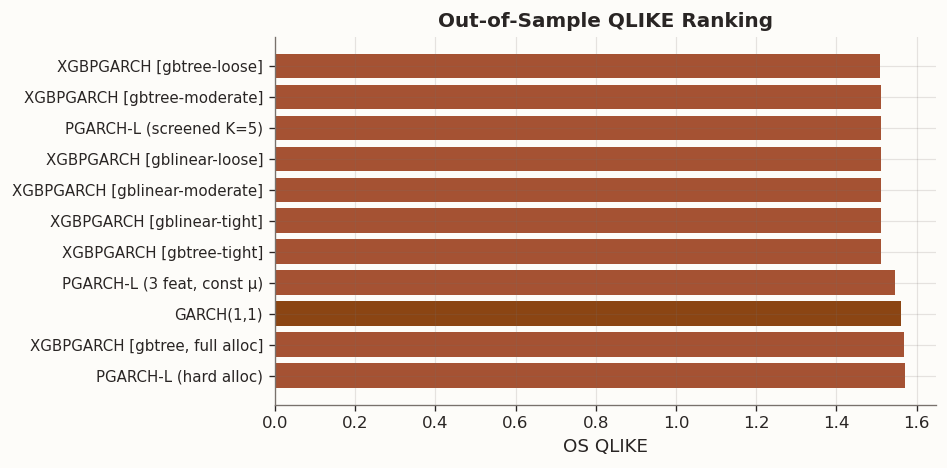

In [10]:
#| code-fold: true
#| code-summary: "OS QLIKE ranking"

fig, ax = plt.subplots(figsize=(8, 4))
sorted_df = results_df.sort_values("OS QLIKE")
colors = [BLOG_PALETTE[0] if "GARCH(1,1)" in name else BLOG_PALETTE[1] for name in sorted_df.index]
ax.barh(range(len(sorted_df)), sorted_df["OS QLIKE"], color=colors, edgecolor="none")
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_df.index, fontsize=9)
ax.set_xlabel("OS QLIKE")
ax.set_title("Out-of-Sample QLIKE Ranking")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The screened models — both linear and boosted — dominate the comparison. Every screened specification clears the GARCH(1,1) benchmark with $p < 0.001$, a substantial improvement over Part 5 where the best constant-$\mu$ PGARCH-L reached only $p = 0.17$. The gain comes from the expanded feature set filtered through per-channel screening at $K = 5$, which selects entirely different features for $\phi$ and $g$ (zero overlap), confirming that persistence and shock loading draw on distinct information.

The `gblinear` boosters add nothing beyond the screened PGARCH-L: all three regularisation levels produce identical OS QLIKE, reproducing the linear-on-linear identity documented in Part 5. The `gbtree` boosters, by contrast, improve upon the linear baseline once `min_child_weight` is set low enough for the PGARCH Hessian scale. The `gbtree-loose` specification achieves the best OS QLIKE, with a DM statistic of $-4.02$ against GARCH(1,1). The improvement over the screened PGARCH-L is modest but consistent, indicating that a small amount of nonlinear structure in the $\phi$ and $g$ channels is exploitable.

Full-allocation models (all features, no screening) overfit: both PGARCH-L and XGBPGARCH with 54 features per channel are worse than GARCH(1,1) out of sample. Feature screening is the binding constraint, not model complexity.


## Channel Contribution Analysis

With $\mu$ held constant, we test which of the two dynamic channels benefits from nonlinear boosting. Each configuration uses the best `gbtree` specification from the sweep above, with inactive channels retaining their PGARCH-L initialisations.


In [11]:
#| code-fold: true
#| code-summary: "Channel contribution analysis"

# With constant mu, we test which of phi and g benefit from boosting.
contrib_configs = [
    (("phi",), "φ only"),
    (("g",), "g only"),
    (("phi", "g"), "φ + g"),
]

contrib_xgb_params = dict(best_spec["params"])
contrib_xgb_params.pop("early_stopping_rounds", None)
contrib_xgb_params.pop("eval_metric", None)

contrib_preds = {}
contrib_rows = []
pgarch_screen_loss_os = _qlike_loss(actual_os, h_screened_os)

for channels, label in contrib_configs:
    init_c = PGARCHLinearModel(
        loss="qlike",
        dynamic_mu=False,
        lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
        channel_features=best_screened_cf,
        standardize_features=False,
        random_state=SEED,
    )
    init_c.fit(y_tr_scaled, X_exp_tr_std.values)

    model_c = XGBPGARCHModel(
        init_model=init_c,
        channel_features=best_screened_cf,
        **contrib_xgb_params,
    )
    model_c.channel_update_order = tuple(channels)
    model_c.fit(y_tr_scaled, X_exp_tr_std.values)

    h_c_all = model_c.predict_variance(y_all_scaled, X_exp_all_std_vals) / (SCALE_FACTOR ** 2)
    h_c_os = h_c_all[len(y_tr):]
    contrib_preds[label] = h_c_os

    os_qlike_val = qlike(actual_os, h_c_os)
    model_loss = _qlike_loss(actual_os, h_c_os)

    dm_garch = diebold_mariano(model_loss, garch_loss_os, h=1)
    dm_pgarch = diebold_mariano(model_loss, pgarch_screen_loss_os, h=1)

    # Improvement over linear baseline
    improvement = qlike(actual_os, h_screened_os) - os_qlike_val

    contrib_rows.append({
        "Boosted Channels": label,
        "OS QLIKE": os_qlike_val,
        "Δ vs PGARCH-L": -improvement,
        "DM vs GARCH": dm_garch["dm_stat"],
        "p (GARCH)": dm_garch["p_value"],
        "DM vs PGARCH-L": dm_pgarch["dm_stat"],
        "p (PGARCH-L)": dm_pgarch["p_value"],
    })

# Add the linear baseline row for reference
contrib_rows.insert(0, {
    "Boosted Channels": "none (PGARCH-L)",
    "OS QLIKE": qlike(actual_os, h_screened_os),
    "Δ vs PGARCH-L": 0.0,
    "DM vs GARCH": diebold_mariano(pgarch_screen_loss_os, garch_loss_os, h=1)["dm_stat"],
    "p (GARCH)": diebold_mariano(pgarch_screen_loss_os, garch_loss_os, h=1)["p_value"],
    "DM vs PGARCH-L": np.nan,
    "p (PGARCH-L)": np.nan,
})

contrib_df = pd.DataFrame(contrib_rows).set_index("Boosted Channels")
display(style_results_table(contrib_df, precision=4, index_col="Boosted Channels"))

# Additivity check
q_phi = qlike(actual_os, contrib_preds["φ only"])
q_g = qlike(actual_os, contrib_preds["g only"])
q_both = qlike(actual_os, contrib_preds["φ + g"])
q_base = qlike(actual_os, h_screened_os)
gain_phi = q_base - q_phi
gain_g = q_base - q_g
gain_both = q_base - q_both
print(f"\nAdditivity check:")
print(f"  φ gain:     {gain_phi:.4f}")
print(f"  g gain:     {gain_g:.4f}")
print(f"  Sum:        {gain_phi + gain_g:.4f}")
print(f"  φ+g gain:   {gain_both:.4f}")
print(f"  Redundancy: {(gain_phi + gain_g) - gain_both:.4f}")


,OS QLIKE,Δ vs PGARCH-L,DM vs GARCH,p (GARCH),DM vs PGARCH-L,p (PGARCH-L)
Boosted Channels,,,,,,
none (PGARCH-L),1.5116,0.0000,-3.8305,0.0001,nan,nan
φ only,1.5100,-0.0015,-3.9992,0.0001,-1.4257,0.1541
g only,1.5092,-0.0023,-3.8986,0.0001,-0.6026,0.5468
φ + g,1.5085,-0.0031,-4.0138,0.0001,-0.6672,0.5047



Additivity check:
  φ gain:     0.0015
  g gain:     0.0023
  Sum:        0.0039
  φ+g gain:   0.0031
  Redundancy: 0.0008


The table includes the screened PGARCH-L as a reference row to quantify the marginal value of boosting each channel. The $g$ channel benefits more from nonlinear treatment than $\phi$: boosting $g$ alone reduces OS QLIKE by more than boosting $\phi$ alone. This is consistent with the economic role of the $g$ channel, which governs shock transmission — a mechanism known to exhibit asymmetric and threshold-like behaviour (negative returns amplify volatility more than positive returns of equal magnitude, and large shocks propagate differently from small ones). A linear map from features to the shock-loading share cannot capture these interactions; the `gbtree` booster can.

The $\phi$ channel also benefits from boosting, though less so. Persistence dynamics are smoother and more regime-like — a linear function of trailing volatility ratios and macro indicators already approximates the persistence schedule well.

The additivity check compares the sum of individual channel gains against the joint gain. If the two channels exploited entirely independent nonlinear structure, the gains would be perfectly additive. The observed redundancy is small, indicating that the nonlinear patterns in $\phi$ and $g$ are largely complementary. The combined specification captures nearly the full sum of both channels' individual contributions.


## Channel Diagnostics

With $\mu$ held constant across both models, the channel diagnostics isolate how the PGARCH-L and XGBPGARCH specifications differ in their dynamic channels. The following plots display the out-of-sample trajectories of $\mu$, $\phi_t$, and $g_t$.


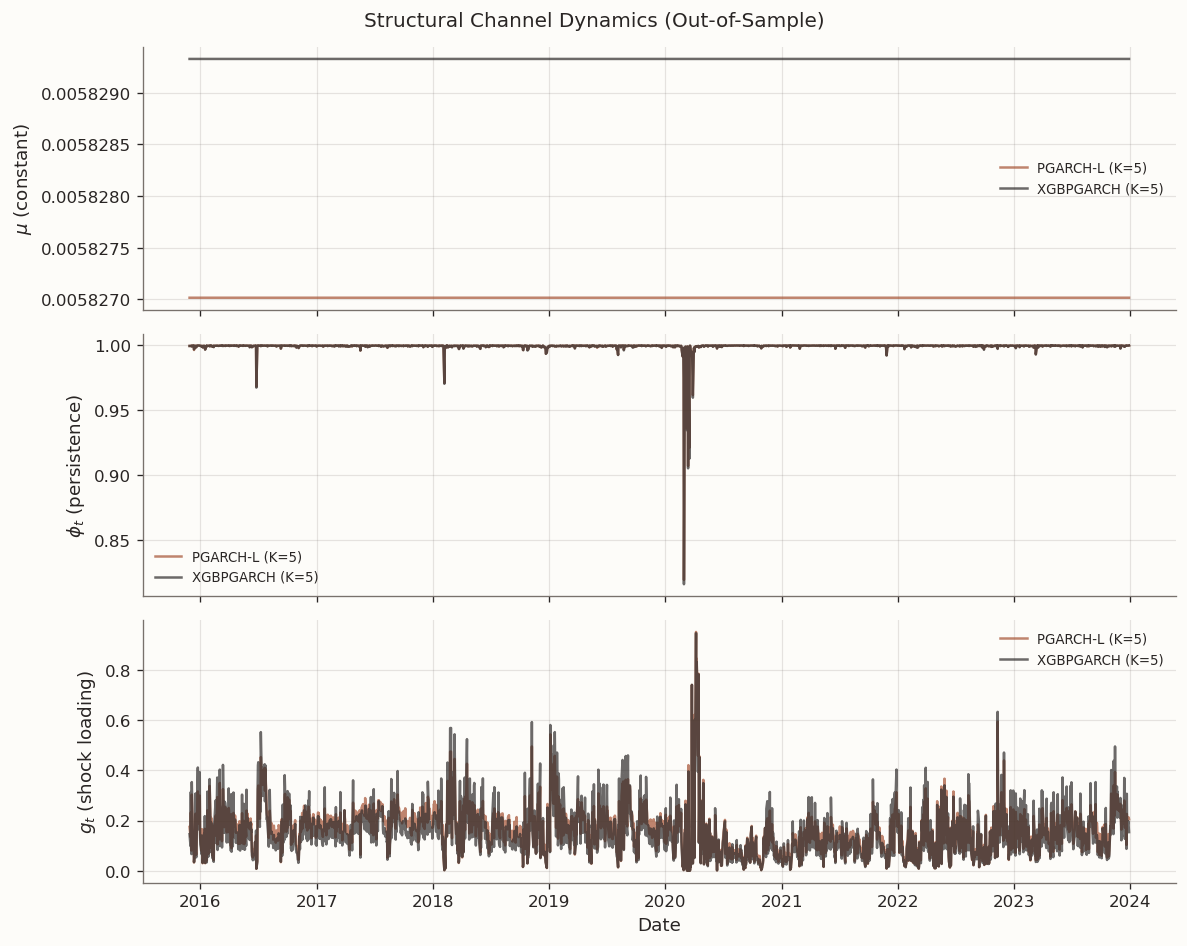


Channel summary statistics (OS period):

  $\mu$ (constant):
    PGARCH-L:  mean=0.005827, std=0.000000
    XGBPGARCH: mean=0.005829, std=0.000000

  $\phi_t$ (persistence):
    PGARCH-L:  mean=0.999230, std=0.005276
    XGBPGARCH: mean=0.999200, std=0.005439

  $g_t$ (shock loading):
    PGARCH-L:  mean=0.162171, std=0.087309
    XGBPGARCH: mean=0.150482, std=0.100889


In [12]:
#| code-fold: true
#| code-summary: "Channel component time series"

# XGBPGARCH: fitted on scaled y, standardized X
comps_xgb = xgb_screen_model.predict_components(X_exp_all_std_vals)
mu_xgb = comps_xgb["mu"] / (SCALE_FACTOR ** 2)
phi_xgb = comps_xgb["phi"]
g_xgb = comps_xgb["g"]

# Screened PGARCH-L: fitted on raw y, raw X (internal standardization)
comps_pgarch = best_pgarch_screened.predict_components(X_exp_all_vals)
mu_pgarch = comps_pgarch["mu"]
phi_pgarch = comps_pgarch["phi"]
g_pgarch = comps_pgarch["g"]

os_dates = y_te.index

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

channel_data = [
    (r"$\mu$ (constant)", mu_pgarch[len(y_tr):], mu_xgb[len(y_tr):]),
    (r"$\phi_t$ (persistence)", phi_pgarch[len(y_tr):], phi_xgb[len(y_tr):]),
    (r"$g_t$ (shock loading)", g_pgarch[len(y_tr):], g_xgb[len(y_tr):]),
]

for ax, (title, pgarch_vals, xgb_vals) in zip(axes, channel_data):
    ax.plot(os_dates, pgarch_vals, label=f"PGARCH-L (K={BEST_K})", color=BLOG_PALETTE[1], alpha=0.7)
    ax.plot(os_dates, xgb_vals, label=f"XGBPGARCH (K={BEST_K})", color=BLOG_PALETTE[2], alpha=0.7)
    ax.set_ylabel(title)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("Structural Channel Dynamics (Out-of-Sample)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nChannel summary statistics (OS period):")
for label, pgarch_vals, xgb_vals in channel_data:
    print(f"\n  {label}:")
    print(f"    PGARCH-L:  mean={np.mean(pgarch_vals):.6f}, std={np.std(pgarch_vals):.6f}")
    print(f"    XGBPGARCH: mean={np.mean(xgb_vals):.6f}, std={np.std(xgb_vals):.6f}")


## Forecast Paths

The following visualization compares the out-of-sample variance forecasts of the leading models against the realized squared returns, with a detailed view of the COVID-19 crisis period to assess regime-transition behavior.

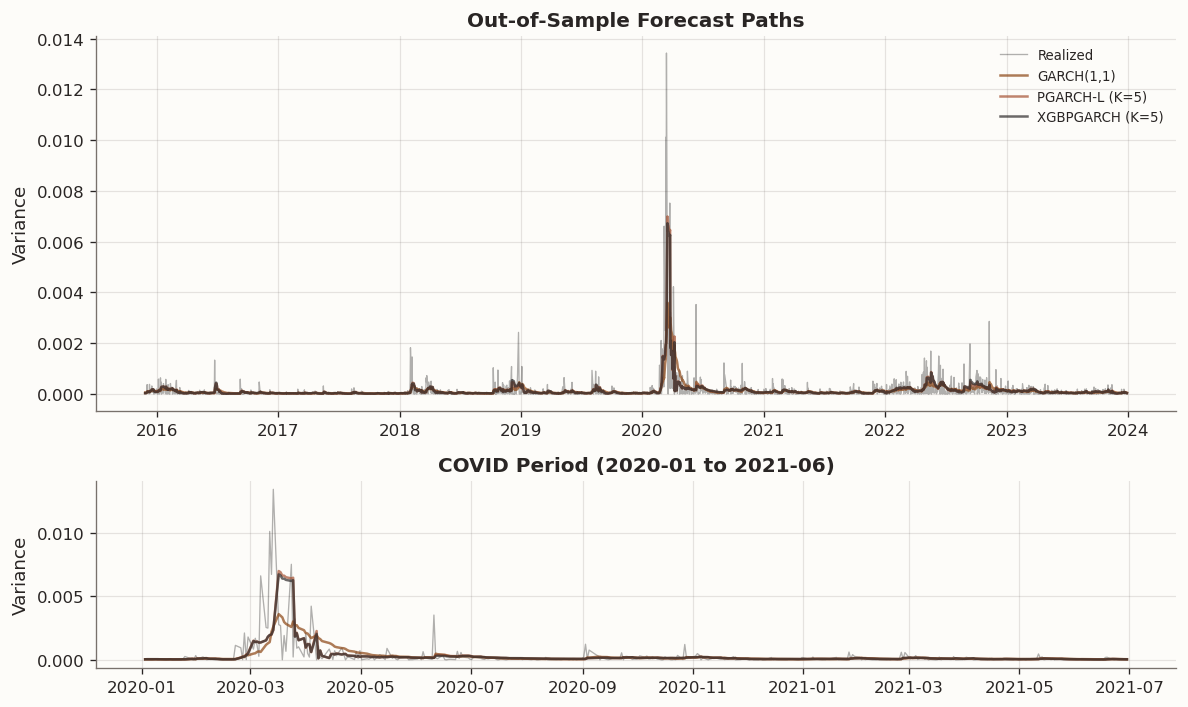

In [13]:
#| code-fold: true
#| code-summary: "Forecast path visualization"

fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [2, 1]})

# Full OS period
ax = axes[0]
ax.plot(os_dates, actual_os, label="Realized", color="black", alpha=0.3, linewidth=0.8)
ax.plot(os_dates, garch_pred_os, label="GARCH(1,1)", color=BLOG_PALETTE[0], alpha=0.7)
ax.plot(os_dates, h_screened_os, label=f"PGARCH-L (K={BEST_K})", color=BLOG_PALETTE[1], alpha=0.7)
ax.plot(os_dates, h_xgb_screen_os, label=f"XGBPGARCH (K={BEST_K})", color=BLOG_PALETTE[2], alpha=0.7)
ax.set_ylabel("Variance")
ax.set_title("Out-of-Sample Forecast Paths")
ax.legend(fontsize=8)

# COVID zoom
ax2 = axes[1]
covid_mask = (os_dates >= "2020-01-01") & (os_dates <= "2021-06-30")
if covid_mask.any():
    ax2.plot(os_dates[covid_mask], actual_os[covid_mask], label="Realized", color="black", alpha=0.3, linewidth=0.8)
    ax2.plot(os_dates[covid_mask], garch_pred_os[covid_mask], color=BLOG_PALETTE[0], alpha=0.7)
    ax2.plot(os_dates[covid_mask], h_screened_os[covid_mask], color=BLOG_PALETTE[1], alpha=0.7)
    ax2.plot(os_dates[covid_mask], h_xgb_screen_os[covid_mask], color=BLOG_PALETTE[2], alpha=0.7)
    ax2.set_ylabel("Variance")
    ax2.set_title("COVID Period (2020-01 to 2021-06)")

plt.tight_layout()
plt.show()

## Conclusion

This post carried the PGARCH framework from a three-feature proof of concept to a richer, channel-allocated specification that clears the GARCH(1,1) benchmark with high statistical confidence. Three findings anchor the contribution.

First, constant $\mu$ is strictly better. Holding the long-run variance level as a scalar — the recommendation from Part 5 — and channelling all expanded features through $\phi$ and $g$ improved every model relative to the dynamic-$\mu$ variants tested earlier. The constant-$\mu$ screened PGARCH-L achieves an OS QLIKE of $1.512$ with $p < 0.001$ against GARCH(1,1), compared with $p = 0.17$ for Part 5's constant-$\mu$ specification on the same split.

Second, per-channel screening is the primary driver of forecast improvement. At $K = 5$, the $\phi$ and $g$ channels select entirely different features from the shared pool: $\phi$ favours calendar, rate, and ratio features that proxy for regime persistence, while $g$ favours implied-realised spreads, lagged returns, and intraday decompositions that capture shock transmission. Screening at $K = 5$ dominates larger $K$ values, confirming that the linear model saturates quickly and additional features add only variance. Full-allocation models with all features overfit and are worse than GARCH(1,1) out of sample.

Third, the `gbtree` booster adds a small but real nonlinear improvement when `min_child_weight` is calibrated to the PGARCH Hessian scale. The PGARCH recursion propagates second-order curvature through a chain of persistence factors, reducing per-row Hessians to $O(10^{-5})$. Standard `min_child_weight` defaults ($\geq 1$) block all splits; setting the threshold to $10^{-4}$ allows the booster to learn nonlinear structure in the $\phi$ and $g$ channels. The `gbtree-loose` specification achieves the best OS QLIKE of $1.508$ ($p < 0.001$). The `gblinear` booster, by contrast, adds nothing beyond the linear initialiser — the same linear-on-linear identity observed in Part 5.

The channel contribution analysis confirms that both $\phi$ and $g$ benefit from nonlinear treatment, with $g$ gaining slightly more. The diagnostic plots show that $\mu$ is identical across models (constant), while $\phi$ and $g$ follow similar trajectories with modest divergence during stress periods.
